# 04 - Model Benchmark Sweep

Trains every configured model on the best lookback window selected in notebook 03 and writes the top model back to `debug_exports`.

In [10]:
!pip install pymongo catboost

ERROR: Operation cancelled by user


In [15]:
import os
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from pymongo import MongoClient
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import tensorflow as tf

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

load_dotenv(str(ROOT / ".env"), override=False)

def load_colab_secrets(keys: list[str]) -> None:
    try:
        from google.colab import userdata
    except Exception:
        return
    for key in keys:
        if os.getenv(key):
            continue
        try:
            value = userdata.get(key)
        except Exception:
            value = None
        if value:
            os.environ[key] = value

load_colab_secrets(["MONGO_URI", "MONGO_DB_NAME"])

sns.set_theme(style="whitegrid")

@dataclass
class ModelConfig:
    name: str
    type: str
    params: dict


MODEL_CONFIGS = [
    ModelConfig(name="lightgbm", type="lgbm", params={"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31}),
    ModelConfig(name="xgboost", type="xgb", params={"n_estimators": 300, "learning_rate": 0.05, "max_depth": 6}),
    ModelConfig(name="catboost", type="cat", params={"iterations": 400, "learning_rate": 0.05, "depth": 6}),
    ModelConfig(name="random_forest", type="rf", params={"n_estimators": 400, "max_depth": 20, "n_jobs": -1}),
    ModelConfig(name="extra_trees", type="extra", params={"n_estimators": 400, "max_depth": 20, "n_jobs": -1}),
    ModelConfig(name="gradient_boosting", type="gbr", params={"n_estimators": 300, "learning_rate": 0.05}),
    ModelConfig(name="ridge_regression", type="ridge", params={"alpha": 1.0}),
    ModelConfig(name="linear_regression", type="linreg", params={}),
    ModelConfig(name="gru", type="gru", params={"units": 64, "epochs": 15, "batch_size": 64}),
    ModelConfig(name="lstm", type="lstm", params={"units": 64, "epochs": 15, "batch_size": 64}),
]

TOP_FEATURES = [
    "wind_speed_10m_rolling_std_168h",
    "hour_sin",
    "is_day",
    "hour_of_day",
    "solar_radiation_category",
    "european_aqi_rolling_std_168h",
    "day_of_week_cos",
    "hour_cos",
    "european_aqi_rolling_std_24h",
    "european_aqi_rolling_min_168h",
    "pm10_rolling_mean_24h",
    "hour_traffic_weight",
    "days_since_last_rain",
    "relative_humidity_2m_rolling_min_24h",
    "pm10_rolling_mean_48h",
    "european_aqi_rolling_std_48h",
    "day_of_week",
    "pm10_rolling_mean_12h",
    "pm10_rolling_std_168h",
    "european_aqi_rolling_mean_3h",
    "day_of_week_sin",
    "european_aqi_rolling_min_3h",
    "pm2_5_rolling_mean_6h",
    "precipitation_cumulative_72h",
    "nitrogen_dioxide_lag_6h",
    "pm10_rolling_std_24h",
    "pm2_5_rolling_min_3h",
    "is_evening_rush",
    "pm2_5_rolling_min_6h",
    "pm2_5_rolling_mean_12h",
    "oxidant_index",
    "european_aqi_rolling_std_12h",
    "pressure_change_6h",
    "nitrogen_dioxide_lag_1h",
    "pm2_5_rolling_mean_3h",
    "pm10_rolling_min_3h",
    "relative_humidity_2m_rolling_std_24h",
    "weekend_traffic_factor",
    "european_aqi_lag_1h",
    "wind_speed_10m_rolling_min_48h",
]

ARTIFACTS_DIR = Path("/content/debug_exports")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

horizon = 72
best_window_days = 80

SEED = 42
SPLIT_RATIO = 0.9
TARGET_MODEL_COUNT = 10
MAX_DL_MODELS = 2
DL_TYPES = {"gru", "lstm"}
TREE_MODEL_NAMES = {"lightgbm", "xgboost", "catboost", "random_forest", "extra_trees", "gradient_boosting"}

CPU_OVERRIDES = {
    "xgboost": {"tree_method": "hist", "n_jobs": 1, "random_state": SEED},
    "catboost": {"task_type": "CPU", "thread_count": 1, "random_seed": SEED},
    "extra_trees": {"n_jobs": 1, "random_state": SEED},
    "random_forest": {"n_jobs": 1, "random_state": SEED},
    "lightgbm": {"device_type": "cpu", "n_jobs": 1, "random_state": SEED},
    "gradient_boosting": {"random_state": SEED},
}

BENCHMARK_MODEL_NAMES = [config.name for config in MODEL_CONFIGS]

def apply_cpu_overrides(config: ModelConfig) -> ModelConfig:
    overrides = CPU_OVERRIDES.get(config.name, {})
    if not overrides:
        return config
    params = {**config.params, **overrides}
    return ModelConfig(name=config.name, type=config.type, params=params)


def get_mongo_client() -> MongoClient:
    uri = os.getenv("MONGO_URI")
    if not uri:
        raise ValueError("MONGO_URI is required")
    return MongoClient(uri)


def get_database():
    client = get_mongo_client()
    db_name = os.getenv("MONGO_DB_NAME", "aqi_predictor")
    return client.get_database(db_name)


def evaluate_forecast(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}


def per_horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    metrics = {}
    horizons = y_true.shape[1]
    for idx in [23, 47, 71]:
        if idx < horizons:
            metrics[f"rmse_{idx+1}h"] = float(np.sqrt(mean_squared_error(y_true[:, idx], y_pred[:, idx])))
    return metrics


def _build_dl_model(model_type: str, input_shape: Tuple[int, int], output_steps: int, units: int):
    model = tf.keras.Sequential()
    if model_type == "gru":
        model.add(tf.keras.layers.GRU(units, input_shape=input_shape, return_sequences=False))
    else:
        model.add(tf.keras.layers.LSTM(units, input_shape=input_shape, return_sequences=False))
    model.add(tf.keras.layers.Dense(128, activation="relu"))
    model.add(tf.keras.layers.Dense(output_steps))
    model.compile(optimizer="adam", loss="mse")
    return model


def _prepare_sequence_data(
    features: pd.DataFrame, target: pd.Series, lookback: int, horizon: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X, y, start_indices = [], [], []
    values = features.values
    target_values = target.values
    for idx in range(lookback, len(features) - horizon):
        X.append(values[idx - lookback : idx])
        y.append(target_values[idx : idx + horizon])
        start_indices.append(idx)
    return np.array(X), np.array(y), np.array(start_indices)


def train_model(
    config: ModelConfig,
    x_train: pd.DataFrame,
    y_train: pd.DataFrame,
    x_val: pd.DataFrame,
    y_val: pd.DataFrame,
    horizon: int = 72,
    feature_frame: pd.DataFrame = None,
    target: pd.Series = None,
    split_index: int = None,
) -> Tuple[object, np.ndarray, np.ndarray]:
    if config.type in {"lgbm", "xgb", "cat", "rf", "extra", "gbr", "ridge", "linreg"}:
        if config.type == "lgbm":
            base = lgb.LGBMRegressor(**config.params)
        elif config.type == "xgb":
            base = xgb.XGBRegressor(**config.params)
        elif config.type == "cat":
            base = cb.CatBoostRegressor(**config.params, verbose=False)
        elif config.type == "rf":
            base = RandomForestRegressor(**config.params)
        elif config.type == "extra":
            base = ExtraTreesRegressor(**config.params)
        elif config.type == "ridge":
            base = Ridge(**config.params)
        elif config.type == "linreg":
            base = LinearRegression(**config.params)
        else:
            base = GradientBoostingRegressor(**config.params)

        if config.type in {"rf", "extra", "ridge", "linreg"}:
            model = base
            model.fit(x_train, y_train)
        else:
            model = MultiOutputRegressor(base)
            model.fit(x_train, y_train)
        preds = model.predict(x_val)
        return model, preds, y_val.values

    if feature_frame is None or target is None or split_index is None:
        raise ValueError("feature_frame, target, and split_index are required for DL models")

    lookback = 24
    X_seq, y_seq, start_indices = _prepare_sequence_data(feature_frame, target, lookback, horizon)
    train_mask = start_indices + horizon <= split_index
    val_mask = start_indices >= split_index

    if not train_mask.any() or not val_mask.any():
        raise ValueError("Not enough sequences for the requested train/validation split")

    X_train, X_val = X_seq[train_mask], X_seq[val_mask]
    y_train, y_val = y_seq[train_mask], y_seq[val_mask]

    model = _build_dl_model(
        config.type,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        output_steps=horizon,
        units=config.params.get("units", 64),
    )
    model.fit(
        X_train,
        y_train,
        epochs=config.params.get("epochs", 10),
        batch_size=config.params.get("batch_size", 32),
        verbose=0,
    )
    preds = model.predict(X_val)
    return model, preds, y_val


def build_window_frame(frame: pd.DataFrame, days: int) -> pd.DataFrame:
    latest_timestamp = frame["timestamp"].max()
    window_start = latest_timestamp - pd.Timedelta(days=days)
    return frame.loc[frame["timestamp"] >= window_start].sort_values("timestamp").reset_index(drop=True)


def prepare_training_matrices(feature_frame: pd.DataFrame, target: pd.Series, split_index: int):
    if feature_frame.empty or len(feature_frame) <= horizon:
        return None, None, None, None, None

    max_start = len(target) - horizon
    if max_start <= 0 or split_index <= horizon or split_index >= max_start:
        return None, None, None, None, None

    x = feature_frame.iloc[:max_start].copy()
    y = pd.DataFrame([target.iloc[i : i + horizon].values for i in range(max_start)], index=x.index)
    start_indices = np.arange(max_start)

    train_mask = start_indices + horizon <= split_index
    val_mask = start_indices >= split_index

    if not train_mask.any() or not val_mask.any():
        return None, None, None, None, None

    return x.iloc[train_mask], y.iloc[train_mask], x.iloc[val_mask], y.iloc[val_mask], list(x.columns)


db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("aqi_features_rawalpindi is empty")

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

feature_cols_all = [column for column in data.columns if column != "timestamp"]
feature_cols = [feature for feature in TOP_FEATURES if feature in data.columns] or feature_cols_all

window_frame = build_window_frame(data, best_window_days)
split_index = int(len(window_frame) * SPLIT_RATIO)

if split_index <= horizon:
    raise ValueError("Not enough rows to create a leakage-safe split")

target = window_frame["european_aqi"].astype(float)
feature_frame = window_frame[feature_cols].apply(pd.to_numeric, errors="coerce").ffill().fillna(0.0)
feature_frame = feature_frame.loc[:, feature_frame.nunique(dropna=True) > 1].copy()

x_train, y_train, x_val, y_val, used_features = prepare_training_matrices(feature_frame, target, split_index)

if x_train is None or y_train is None or x_val is None or y_val is None:
    raise ValueError("Unable to prepare benchmark matrices for the selected window and split")

Running benchmark for lightgbm...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5953
[LightGBM] [Info] Number of data points in the train set: 1657, number of used features: 40
[LightGBM] [Info] Start training from score 58.700664
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5953
[LightGBM] [Info] Number of data points in the train set: 1657, number of used features: 40
[LightGBM] [Info] Start training from score 58.697646
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_row_wise=true` to remove the ov

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Finished gru: rmse=18.4098
Running benchmark for lstm...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Finished lstm: rmse=18.3018


,model,type,window_days,rows_after_prep,features_used,rmse,mae,r2,rmse_24h,rmse_48h,rmse_72h
0,lightgbm,lgbm,80,1778,40,12.446902,8.405348,0.503494,8.509114,13.479367,16.960659
1,xgboost,xgb,80,1778,40,12.457296,8.407620,0.512645,8.942618,13.374138,18.205351
2,catboost,cat,80,1778,40,11.059894,7.950400,0.619749,8.362500,10.936449,18.542370
3,random_forest,rf,80,1778,40,12.180505,9.183780,0.475354,10.093284,13.081513,18.190826
4,extra_trees,extra,80,1778,40,11.701278,8.201754,0.595672,8.593243,10.946469,20.236210
5,gradient_boosting,gbr,80,1778,40,11.684762,8.652385,0.549434,8.122023,12.575693,18.264234
6,ridge_regression,ridge,80,1778,40,13.793965,9.502007,0.443342,9.210455,13.313093,23.875294
7,linear_regression,linreg,80,1778,40,13.794115,9.501140,0.443104,9.210693,13.321161,23.881000
8,gru,gru,80,1778,40,18.409777,14.197530,-0.146726,14.080157,18.260120,27.293999
9,lstm,lstm,80,1778,40,18.301778,14.104111,-0.146170,13.565129,17.893730,27.147353


Saved /content/debug_exports/model_benchmark_metrics.csv
Best model: catboost
Best tree model: catboost


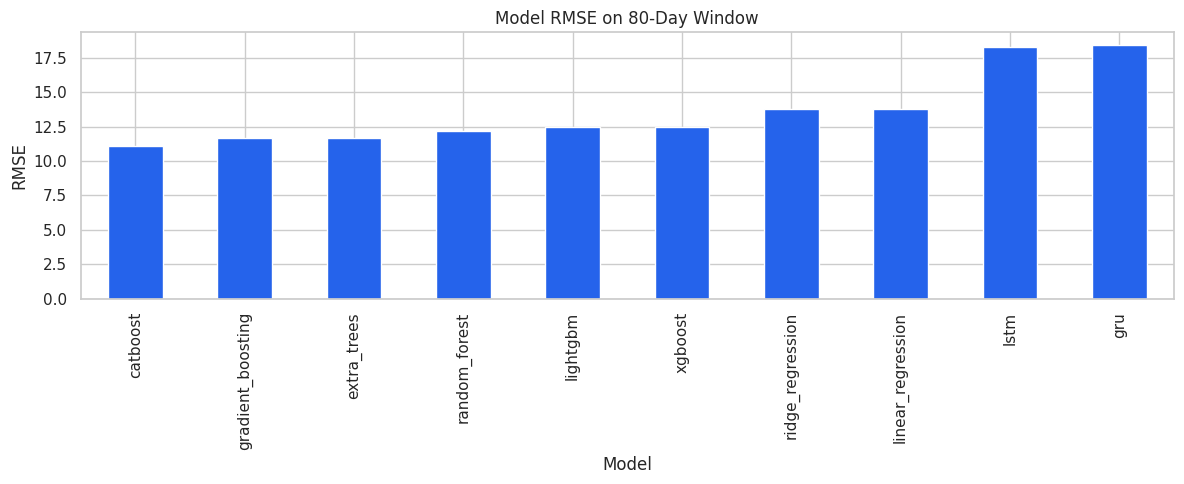

In [16]:
results = []
benchmark_model_names = BENCHMARK_MODEL_NAMES
model_lookup = {config.name: config for config in MODEL_CONFIGS}
missing_models = [name for name in benchmark_model_names if name not in model_lookup]
if missing_models:
    print(f"Skipping missing model configs: {missing_models}")
benchmark_models = [apply_cpu_overrides(model_lookup[name]) for name in benchmark_model_names if name in model_lookup]
if not benchmark_models:
    raise ValueError("No benchmark models available for the configured shortlist")

rows_after_prep = len(x_train) + len(x_val)

for config in benchmark_models:
    print(f"Running benchmark for {config.name}...")
    try:
        model, preds, y_true = train_model(
            config,
            x_train,
            y_train,
            x_val,
            y_val,
            horizon=horizon,
            feature_frame=feature_frame,
            target=target,
            split_index=split_index,
        )
        metrics = evaluate_forecast(y_true, preds)
        metrics.update(per_horizon_metrics(y_true, preds))
        results.append(
            {
                "model": config.name,
                "type": config.type,
                "window_days": best_window_days,
                "rows_after_prep": rows_after_prep,
                "features_used": len(used_features),
                **metrics,
            }
        )
        print(f"Finished {config.name}: rmse={metrics['rmse']:.4f}")
    except Exception as exc:
        # Ensure result schema is consistent so subsequent DataFrame ops don't fail
        print(f"Model {config.name} failed: {exc}")
        results.append(
            {
                "model": config.name,
                "type": config.type,
                "window_days": best_window_days,
                "rows_after_prep": rows_after_prep,
                "features_used": len(used_features),
                "rmse": float("nan"),
                "mae": float("nan"),
                "r2": float("nan"),
                "error": str(exc),
            }
        )

results_df = pd.DataFrame(results)
results_path = ARTIFACTS_DIR / "model_benchmark_metrics.csv"
results_df.to_csv(results_path, index=False)

valid_results = results_df.dropna(subset=["rmse"]).copy()
if valid_results.empty:
    raise ValueError("All benchmark runs failed")

valid_results = valid_results.sort_values(["rmse", "model"], na_position="last").reset_index(drop=True)
best_row = valid_results.iloc[0]
best_model_name = str(best_row["model"])
best_tree_results = valid_results[valid_results["model"].isin(TREE_MODEL_NAMES)].copy()
if not best_tree_results.empty:
    best_tree_results = best_tree_results.sort_values(["rmse", "model"], na_position="last").reset_index(drop=True)
    best_tree_model_name = str(best_tree_results.iloc[0]["model"])
else:
    best_tree_model_name = best_model_name

with open(ARTIFACTS_DIR / "best_model_name.txt", "w", encoding="utf-8") as handle:
    handle.write(best_model_name)

with open(ARTIFACTS_DIR / "best_tree_model_name.txt", "w", encoding="utf-8") as handle:
    handle.write(best_tree_model_name)

with open(ARTIFACTS_DIR / "best_model_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "best_model_name": best_model_name,
            "best_model_type": str(best_row["type"]),
            "best_window_days": best_window_days,
            "rmse": float(best_row["rmse"]),
            "mae": float(best_row["mae"]),
            "r2": float(best_row["r2"]),
            "rows_after_prep": int(best_row["rows_after_prep"]),
            "features_used": int(best_row["features_used"]),
        },
        handle,
        indent=2,
    )

display(results_df)

fig, ax = plt.subplots(figsize=(12, 5))
valid_results.sort_values("rmse").plot(
    kind="bar",
    x="model",
    y="rmse",
    ax=ax,
    color="#2563eb",
    legend=False,
)
ax.set_title(f"Model RMSE on {best_window_days}-Day Window")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
plt.tight_layout()

print(f"Saved {results_path}")
print(f"Best model: {best_model_name}")
print(f"Best tree model: {best_tree_model_name}")